<a href="https://colab.research.google.com/github/giugnom3/Algorithms/blob/main/W4HW_GiugnoMaria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Data Preprocessing Lab**

## Maria Giugno
CSC 576

# Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder

# Remove Duplicates using Keep First *drop_duplicates(keep='first')*

In [23]:
# Create dataset
df = pd.DataFrame({
    "ID": [1, 2, 3, 4, 4, 5, 6, 6],
    "Name": ["Alice", "Bob", "Charlie", "David", "David", "Eve", "Frank", "Frank"],
    "Age": [25, 30, 35, 40, 40, 28, 50, 50]
})

df

,ID,Name,Age
0,1,Alice,25
1,2,Bob,30
2,3,Charlie,35
3,4,David,40
4,4,David,40
5,5,Eve,28
6,6,Frank,50
7,6,Frank,50


In [13]:
# Remove duplicate using keep first
df_no_duplicate = df.drop_duplicates(keep='first')

df_no_duplicate

,ID,Name,Age
0,1,Alice,25
1,2,Bob,30
2,3,Charlie,35
3,4,David,40
5,5,Eve,28
6,6,Frank,50


# Delete Rows & Columns with Missing Data using dropna()

In [22]:
import pandas as pd

# Create dataset
data2 = {
    "Name": ["Alice", "Bob", "Charlie", "David", "Eve"],
    "Age": [25, 30, None, 40, 28],
    "Salary": [50000, 60000, 55000, None, 58000]
}

df2 = pd.DataFrame(data2)
df2

,Name,Age,Salary
0,Alice,25.0,50000.0
1,Bob,30.0,60000.0
2,Charlie,NaN,55000.0
3,David,40.0,NaN
4,Eve,28.0,58000.0


In [15]:
# Deleting rows with missing values
df2_no_missing = df2.dropna()

print("Dataset after removing rows with missing values:")
df2_no_missing

Dataset after removing rows with missing values:


,Name,Age,Salary
0,Alice,25.0,50000.0
1,Bob,30.0,60000.0
4,Eve,28.0,58000.0


In [16]:
# Deleting columns with missing values
df2_deleted_columns = df2.dropna(axis=1)

print("Dataset after deleting columns with missing values:")
df2_deleted_columns

Dataset after deleting columns with missing values:


,Name
0,Alice
1,Bob
2,Charlie
3,David
4,Eve


# Fill in Missing Data with Zeros using fillna()

In [24]:
# Fill missing values with 0
df_zero = df2.copy()

df_zero.fillna(0, inplace=True)

df_zero

,Name,Age,Salary
0,Alice,25.0,50000.0
1,Bob,30.0,60000.0
2,Charlie,0.0,55000.0
3,David,40.0,0.0
4,Eve,28.0,58000.0


# Mean Imputation using .assign()

In [20]:
# Calculate mean values
mean_age = df2["Age"].mean()
mean_salary = df2["Salary"].mean()

print("Charlie Mean Age:", mean_age)
print("David Mean Salary:", mean_salary)

Charlie Mean Age: 30.75
David Mean Salary: 55750.0


In [21]:
# Assign Mean values
df_mean = df2.copy()

df_mean = df_mean.assign(
    Age = df_mean["Age"].fillna(df_mean["Age"].mean()),
    Salary = df_mean["Salary"].fillna(df_mean["Salary"].mean())
)

df_mean

,Name,Age,Salary
0,Alice,25.00,50000.0
1,Bob,30.00,60000.0
2,Charlie,30.75,55000.0
3,David,40.00,55750.0
4,Eve,28.00,58000.0


# Median and Mode Imputation using .fillna()

In [34]:
# Create dataset
data = {
    "Name": ["Alice", "Bob", "Charlie", "David", "Eve"],
    "Age": [25, 30, None, 40, 28],
    "Salary": [50000, 60000, 55000, None, 58000],
    "City": ["New York", "Los Angeles", None, "Chicago", "Houston"]
}

df = pd.DataFrame(data)

print("Original Dataset:\n")
df

Original Dataset:



,Name,Age,Salary,City
0,Alice,25.0,50000.0,New York
1,Bob,30.0,60000.0,Los Angeles
2,Charlie,NaN,55000.0,None
3,David,40.0,NaN,Chicago
4,Eve,28.0,58000.0,Houston


In [36]:
# Calculating Median values
median_age = df["Age"].median()
median_salary = df["Salary"].median()

print("Median Age:", median_age)
print("Median Salary:", median_salary)

df_median = df.copy()

Median Age: 29.0
Median Salary: 56500.0


In [37]:
# Apply Median Imputation to numeric columns
df_median["Age"] = df_median["Age"].fillna(median_age)
df_median["Salary"] = df_median["Salary"].fillna(median_salary)

In [38]:
# Apply Median Imputation to City
mode_city = df_median["City"].mode()[0]

print("Mode City:", mode_city)

df_median["City"] = df_median["City"].fillna(mode_city)


Mode City: Chicago


In [39]:
print("\nDataset After Median and Mode Imputation:\n")

df_median



Dataset After Median and Mode Imputation:



,Name,Age,Salary,City
0,Alice,25.0,50000.0,New York
1,Bob,30.0,60000.0,Los Angeles
2,Charlie,29.0,55000.0,Chicago
3,David,40.0,56500.0,Chicago
4,Eve,28.0,58000.0,Houston


In [40]:
# Create dataset
data = {
    "Name": ["Alice", "Bob", "Charlie", "David", "Eve"],
    "Age": [25, 30, None, 40, 28],
    "Salary": [50000, 60000, 55000, None, 58000],
    "City": ["New York", "Los Angeles", None, "Chicago", "Houston"]
}

df = pd.DataFrame(data)

print("Original Dataset:\n")
df

Original Dataset:



,Name,Age,Salary,City
0,Alice,25.0,50000.0,New York
1,Bob,30.0,60000.0,Los Angeles
2,Charlie,NaN,55000.0,None
3,David,40.0,NaN,Chicago
4,Eve,28.0,58000.0,Houston


In [41]:
# Creating a copy of the dataset for Mode Imputation
df_mode = df.copy()

mode_age = df_mode["Age"].mode()[0]
mode_salary = df_mode["Salary"].mode()[0]
mode_city = df_mode["City"].mode()[0]

print("Mode Age:", mode_age)
print("Mode Salary:", mode_salary)
print("Mode City:", mode_city)

Mode Age: 25.0
Mode Salary: 50000.0
Mode City: Chicago


In [43]:
# Filling missing values with mode
df_mode["Age"] = df_mode["Age"].fillna(mode_age)
df_mode["Salary"] = df_mode["Salary"].fillna(mode_salary)
df_mode["City"] = df_mode["City"].fillna(mode_city)

print("\nDataset after Mode Imputation:\n")
df_mode


Dataset after Mode Imputation:



,Name,Age,Salary,City
0,Alice,25.0,50000.0,New York
1,Bob,30.0,60000.0,Los Angeles
2,Charlie,25.0,55000.0,Chicago
3,David,40.0,50000.0,Chicago
4,Eve,28.0,58000.0,Houston


# Normalization using Min-Max Scaling

In [44]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Generate sample data (10 data points, 2 features)
data = np.array([
    [10, 200],
    [20, 250],
    [30, 300],
    [40, 350],
    [50, 400],
    [60, 450],
    [70, 500],
    [80, 550],
    [90, 600],
    [100, 650]
])

# Convert to DataFrame for better visualization
df = pd.DataFrame(data, columns=["Feature1", "Feature2"])

# Display original data
print("Original Data:")
df


Original Data:


,Feature1,Feature2
0,10,200
1,20,250
2,30,300
3,40,350
4,50,400
5,60,450
6,70,500
7,80,550
8,90,600
9,100,650


In [45]:
# --- Normalization (Min-Max Scaling) ---
scaler_minmax = MinMaxScaler()
normalized_data = scaler_minmax.fit_transform(df)

# Convert normalized data to DataFrame for better visualization
df_normalized = pd.DataFrame(normalized_data, columns=["Feature1", "Feature2"])

# Display normalized data
print("\nNormalized Data (Min-Max Scaling):")
df_normalized



Normalized Data (Min-Max Scaling):


,Feature1,Feature2
0,0.000000,0.000000
1,0.111111,0.111111
2,0.222222,0.222222
3,0.333333,0.333333
4,0.444444,0.444444
5,0.555556,0.555556
6,0.666667,0.666667
7,0.777778,0.777778
8,0.888889,0.888889
9,1.000000,1.000000


# Standardization using Z-Score Scaling

In [46]:
# --- Standardization (Z-score Scaling) ---
scaler_standard = StandardScaler()
standardized_data = scaler_standard.fit_transform(df)

# Convert standardized data to DataFrame for better visualization
df_standardized = pd.DataFrame(standardized_data, columns=["Feature1", "Feature2"])

# Display standardized data
print("\nStandardized Data (Z-score Scaling):")
df_standardized



Standardized Data (Z-score Scaling):


,Feature1,Feature2
0,-1.566699,-1.566699
1,-1.218544,-1.218544
2,-0.870388,-0.870388
3,-0.522233,-0.522233
4,-0.174078,-0.174078
5,0.174078,0.174078
6,0.522233,0.522233
7,0.870388,0.870388
8,1.218544,1.218544
9,1.566699,1.566699


# Outlier Detection using Boxplot

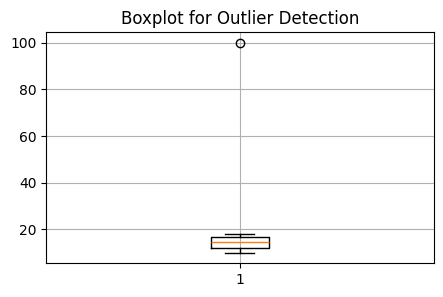

In [47]:
import numpy as np
import matplotlib.pyplot as plt

# Generate sample data with outliers
data = np.array([10, 12, 12, 13, 14, 15, 16, 17, 18, 100])

# Create a boxplot
figure = plt.figure(figsize=(5, 3))
plt.boxplot(data)
plt.title("Boxplot for Outlier Detection")
plt.grid(True)
plt.show()


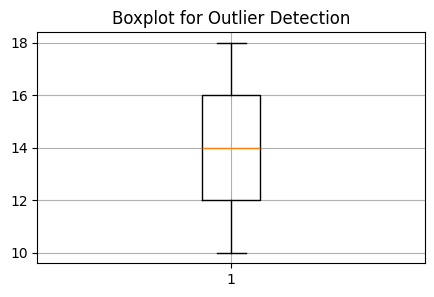

In [48]:
data = np.array([10, 12, 12, 13, 14, 15, 16, 17, 18])

# Create a boxplot
figure = plt.figure(figsize=(5, 3))
plt.boxplot(data)
plt.title("Boxplot for Outlier Detection")
plt.grid(True)
plt.show()


# Outlier Detection using Z-Score Method

In [49]:
import numpy as np
from scipy import stats

# Generate sample data with outliers
data = np.array([10, 12, 12, 13, 14, 15, 16, 17, 18, 100])

# Calculate the Z-scores
z_scores = stats.zscore(data)

# Define the threshold for identifying outliers (commonly 2.5 or 3)
threshold = 2.5  # Adjusted threshold to catch more subtle outliers

# Identify outliers
outliers = np.where(np.abs(z_scores) > threshold)

print("Z-scores:", z_scores)
print("")
print("Outliers indices:", outliers)
print("")
print("Outlier values:", data[outliers])


Z-scores: [-0.49085998 -0.41355919 -0.41355919 -0.3749088  -0.33625841 -0.29760802
 -0.25895763 -0.22030723 -0.18165684  2.9876753 ]

Outliers indices: (array([9]),)

Outlier values: [100]


# Label Encoding

In [50]:
from sklearn.preprocessing import LabelEncoder

# Sample data
data = ["Red", "Green", "Blue", "Red", "Green"]

# Initialize label encoder
label_encoder = LabelEncoder()

# Fit and transform the data
encoded_data = label_encoder.fit_transform(data)

# Display the encoded data
print("Label Encoded Data:", encoded_data)


Label Encoded Data: [2 1 0 2 1]


# One-Hot Encoding

In [51]:
import pandas as pd

# Sample data
data = ["Red", "Green", "Blue", "Red", "Green"]

# Create DataFrame
df = pd.DataFrame(data, columns=["Color"])

# Apply One-Hot Encoding with dtype=int to get 0 and 1
one_hot_encoded = pd.get_dummies(df["Color"], dtype=int)

# Display the One-Hot Encoded Data
print("One-Hot Encoded Data:")
print(one_hot_encoded)


One-Hot Encoded Data:
   Blue  Green  Red
0     0      0    1
1     0      1    0
2     1      0    0
3     0      0    1
4     0      1    0
